
## Regressão Linear Simples

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style()

df = pd.read_csv("http://dl.dropboxusercontent.com/s/g8cgvjiorjbz54p/precificacao_housing.csv?dl=0")

df.head()

,GrLivArea,SalePrice
0,1710,208500
1,1262,181500
2,1786,223500
3,1717,140000
4,2198,250000


O *dataset* importado contém a variável `GrLivArea` contendo o tamanho do imóvel ($m^2$) e a variável alvo `SalePrice` com o preço de venda do mesmo. Vou plotar um gráfico de dispersão para termos ideia de como os pontos estão relacionados.


###Gráfico de dispersão

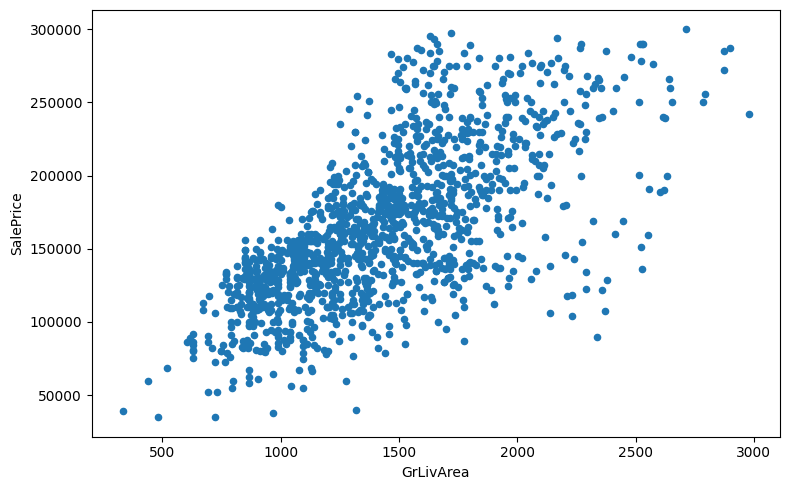

In [3]:
fig,ax = plt.subplots(figsize = (8,5))
df.plot.scatter(x='GrLivArea', y='SalePrice', ax=ax)
plt.tight_layout()


### Regressão Linear Simples com o `scikit-learn`

Dividindo o meu conjunto de dadtos entre *train* e *test* para que sejam mutuamente exclusivos. Será dividido 20% dos dados do *dataset* para o teste final.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [5]:
X = df['GrLivArea'].values.reshape(-1,1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y)

rls_model = LinearRegression()
rls_model.fit(X_train, y_train)

LinearRegression()

Para obter o coeficiente de regressão e intercepto, acesso diretamente a variável `ml_model`

In [7]:
print("Coeficiente:\t", rls_model.coef_)
print("Intercepto:\t", rls_model.intercept_)


Coeficiente:	 [82.3317315]
Intercepto:	 45472.8277321347


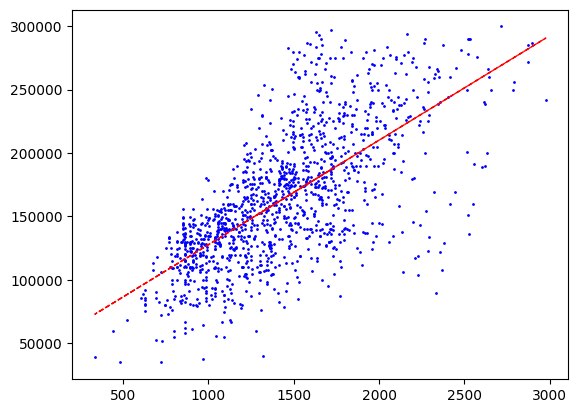

In [8]:
fig, ax = plt.subplots()
ax.scatter(X, y, s=1, color='blue')
ax.plot(X, (rls_model.coef_ * X + rls_model.intercept_), '--r', linewidth=1)

In [9]:
y_pred = rls_model.predict(X_test)

In [10]:
print("R2 Score:\t", r2_score(y_test, y_pred))
print("MAE:\t\t", mean_absolute_error(y_test, y_pred))
print("MSE:\t\t", mean_squared_error(y_test, y_pred))

R2 Score:	 0.41236509118162756
MAE:		 28268.736511278763
MSE:		 1491972189.9061599
